# GyroSwin-FID across multiple latent sources (ID + OOD)

Compute pairwise FID heatmaps (GT-vs-GT and GT-vs-Diff) and a global-FID
table where each row is a (GyroSwin latent source, split) combination.
Splits follow `notebooks/neurips_generate_table1.ipynb`: ID = held-out
in-distribution trajectories, OOD = out-of-distribution trajectories.

Latent sources we evaluate:
* `bottleneck`     — df_unet encoder middle activations (existing default).
* `flux_head (all)`/ levels — pre-MLP physics-targeted features.
* `decoder L=-1` / `L=-2` — df_unet up-block activations 1–2 levels before
  the final 5D output (analogue of InceptionV3 pool3 in classic FID).

Real samples come from the diffusion runner's validation trajectories
(ID + OOD); matched diffusion samples are generated via `runner.sample` with
the same per-trajectory conditioning. Every latent source re-uses the same
df batches so the comparison is apples-to-apples.

Heavy lifting lives in [neurips_fid_gyroswin_latents.py](neurips_fid_gyroswin_latents.py).

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path
PROJECT_ROOT = "/home/u6eb/gutenbru.u6eb/plasmamodelling"
for _p in (PROJECT_ROOT, os.path.join(PROJECT_ROOT, "notebooks")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import torch
from notebooks.neurips_fid_gyroswin_latents import (
    LatentSource, setup, collect_real, generate_diff,
    split_by_traj_set, extract_features, compute_fid_set,
    plot_heatmap_grid, build_table,
)
from notebooks.neurips_generate_table1 import (
    TRAJECTORIES_ID, TRAJECTORIES_OOD, free_cuda,
)

torch.use_deterministic_algorithms(False)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE = {DEVICE}")

/projects/u6eb/miniconda3/envs/diffpl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cuda


In [7]:
# ---- paths (same as notebooks/neurips_generate_table1.ipynb) ---------
DIFF_CKPT_DIR       = "/projects/u6eb/outputs/20260412_180101_948/"
AE_CHECKPOINT       = "/projects/u6eb/outputs/20260405_022851_327/best.pth"
DATA_PREP           = Path("/projects/u6eb/gyrokinetics/preprocessed_kvikio")
GYROSWIN_CHECKPOINT = "/projects/u6eb/checkpoints/gyroswin_xxl_fluxavg_cond_nodrop_l1"

# ---- knobs ----------------------------------------------------------
N_PER_TRAJ        = 32                          # snapshots per traj (real + matched diff)
GEN_BATCH_SIZE    = 32
FEAT_BATCH_SIZE   = 8                           # GyroSwin forward batch (memory)
N_DENOISING_STEPS = 15
PCA_COMPONENTS    = 64

# Latent sources to compare. Add/remove rows freely.
LATENT_SOURCES = [
    LatentSource("bottleneck",      source="bottleneck"),
    LatentSource("flux_head (all)", source="flux_head"),
    LatentSource("flux_head L0",    source="flux_head", level=0),  # bottleneck-mix
    LatentSource("flux_head L1",    source="flux_head", level=1),  # one above
    LatentSource("decoder L=-1",    source="decoder",   level=-1),  # 1 level before 5D
]

# Combined ID+OOD trajectory list -> single diff runner valset.
VALID_H5 = [
    *(t.replace("_ifft_realpotens", "") + ".h5" for t in TRAJECTORIES_ID),
    *(t.replace("_ifft_realpotens", "") + ".h5" for t in TRAJECTORIES_OOD),
]
print(f"trajectories: ID={len(TRAJECTORIES_ID)}  OOD={len(TRAJECTORIES_OOD)}  "
      f"|  latent sources={len(LATENT_SOURCES)}")

trajectories: ID=6  OOD=5  |  latent sources=5


## Build models

In [3]:
runner, gs_model, gs_cfg, gs_cond_keys = setup(
    DIFF_CKPT_DIR, AE_CHECKPOINT, DATA_PREP,
    GYROSWIN_CHECKPOINT, valid_traj_h5_names=VALID_H5, device=DEVICE,
)
print(f"GyroSwin cond_keys: {gs_cond_keys}")
print(f"diff cond_keys:     {sorted(runner.cfg.model.conditioning)}")
print(f"# up_blocks (decoder depth): {len(gs_model.df_unet.up_blocks)}")

Diffusion latent dataset mode: AE
Loaded AE config for normalization from /projects/u6eb/outputs/20260405_022851_327/config.yaml
Loading ['df', 'phi', 'flux'] in dataset
    metadata: 289 files in 0.1s (lightweight=True)
loading aggregated stats from /projects/u6eb/gyrokinetics/preprocessed_kvikio/diff_df_flux_phi_offset80_mu_57f5caf2_df01345_phi012_agg_stats.pkl
    metadata: 11 files in 0.0s (lightweight=True)
Train: 44400
Holdout trajectories (val): 2035
Validation ratio: 0.05
[init] RSS after setup_data: 0.4 GB


/lus/lfs1aip2/projects/u6eb/miniconda3/envs/diffpl/bin/../lib/gcc/aarch64-conda-linux-gnu/14.3.0/../../../../aarch64-conda-linux-gnu/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/lus/lfs1aip2/projects/u6eb/miniconda3/envs/diffpl/bin/../lib/gcc/aarch64-conda-linux-gnu/14.3.0/../../../../aarch64-conda-linux-gnu/bin/ld: /projects/u6eb/miniconda3/envs/diffpl/lib/libcufile.so: undefined reference to `shm_open'
/lus/lfs1aip2/projects/u6eb/miniconda3/envs/diffpl/bin/../lib/gcc/aarch64-conda-linux-gnu/14.3.0/../../../../aarch64-conda-linux-gnu/bin/ld: /projects/u6eb/miniconda3/envs/diffpl/lib/libcufile.so: undefined reference to `shm_unlink'
collect2: error: ld returned 1 exit status


AE parameters: 217.6M
Compression: 604.4x (type: ae). (32, *[32, 16, 85, 32]) -> (256, *[4, 2, 9, 4])
Loading model /projects/u6eb/outputs/20260405_022851_327/best.pth (stopped at epoch 400) 
loading precomputed latents from /projects/u6eb/gyrokinetics/preprocessed_kvikio/diff_train_latents_offset80_mu_57f5caf20c1e_latents_ae327.pkl
latent mean: 0.6872391104698181
latent var: 437.4828796386719
latent l2 norm: 5643.681640625
latent stats -> mean(var): 4.374829e+02, latent_scale: 0.047810
Parameters: 120.5M
[init] RSS after setup_components: 29.9 GB
  diff ckpt epoch=120, params=120.5M


/projects/u6eb/checkpoints/gyroswin_xxl_fluxavg_cond_nodrop_l1/src/models/nd_vit/positional.py:35: UserWarning: Sincos initialization only works if len(grid_size) < dim(returns zero padding otherwise). Switching to random
  warn(


Parameters: 995.1M
GyroSwin cond_keys: ['dg', 'itg', 'q', 's_hat', 'timestep']
diff cond_keys:     ['dg', 'itg', 'q', 's_hat']
# up_blocks (decoder depth): 1


## Collect real validation snapshots and matched diffusion samples

One pass over the (ID + OOD) valset; we then split the result by
trajectory set to recover ID-only and OOD-only views.

In [4]:
real_by_fi = collect_real(runner, n_per_traj=N_PER_TRAJ)
gen_by_fi  = generate_diff(runner, real_by_fi,
                           n_denoising_steps=N_DENOISING_STEPS,
                           batch_size=GEN_BATCH_SIZE)
free_cuda()

real_split = split_by_traj_set(real_by_fi, runner, TRAJECTORIES_ID, TRAJECTORIES_OOD)
gen_split  = split_by_traj_set(gen_by_fi,  runner, TRAJECTORIES_ID, TRAJECTORIES_OOD)

  real samples: 352 across 11 trajs ({0: 32, 1: 32, 2: 32, 3: 32, 4: 32, 5: 32, 6: 32, 7: 32, 8: 32, 9: 32, 10: 32})
  [split] ID: 6 trajs | OOD: 5 trajs
  [split] ID: 6 trajs | OOD: 5 trajs


## Extract features and compute FID for each (latent source, split)

In [6]:
results = {}
for ls in LATENT_SOURCES:
    for split in ("ID", "OOD"):
        if not real_split[split]:
            continue
        print(f"\n--- {ls.name}  ({split})  source={ls.source!r}  level={ls.level} ---")
        real_feats = extract_features(
            gs_model, real_split[split], runner, gs_cond_keys, ls,
            batch_size=FEAT_BATCH_SIZE, device=DEVICE, desc=f"real:{ls.name}/{split}",
        )
        gen_feats = extract_features(
            gs_model, gen_split[split], runner, gs_cond_keys, ls,
            batch_size=FEAT_BATCH_SIZE, device=DEVICE, desc=f"gen:{ls.name}/{split}",
        )
        results[(ls.name, split)] = compute_fid_set(
            real_feats, gen_feats, n_components=PCA_COMPONENTS,
        )
        free_cuda()
        r = results[(ls.name, split)]
        print(f"  global FID = {r['fid_global']:.3f}  "
              f"(raw dim {r['raw_dim']} -> pca {r['pca_dim']}, "
              f"{r['explained_var']:.0%} var)")


--- bottleneck  (ID)  source='bottleneck'  level=None ---
  global FID = 1882959.312  (raw dim 589824 -> pca 64, 71% var)

--- bottleneck  (OOD)  source='bottleneck'  level=None ---
  global FID = 1783543.255  (raw dim 589824 -> pca 64, 71% var)

--- flux_head (all)  (ID)  source='flux_head'  level=None ---
  global FID = 247.827  (raw dim 3072 -> pca 64, 100% var)

--- flux_head (all)  (OOD)  source='flux_head'  level=None ---
  global FID = 306.833  (raw dim 3072 -> pca 64, 100% var)

--- flux_head L0  (ID)  source='flux_head'  level=0 ---
  global FID = 183.941  (raw dim 2048 -> pca 64, 100% var)

--- flux_head L0  (OOD)  source='flux_head'  level=0 ---
  global FID = 103.207  (raw dim 2048 -> pca 64, 100% var)

--- flux_head L1  (ID)  source='flux_head'  level=1 ---
  global FID = 51.117  (raw dim 1024 -> pca 64, 100% var)

--- flux_head L1  (OOD)  source='flux_head'  level=1 ---
  global FID = 190.596  (raw dim 1024 -> pca 64, 100% var)

--- decoder L=-1  (ID)  source='decoder'  

IndexError: decoder_level=-2 out of range for 1 up_blocks

## Heatmaps — ID

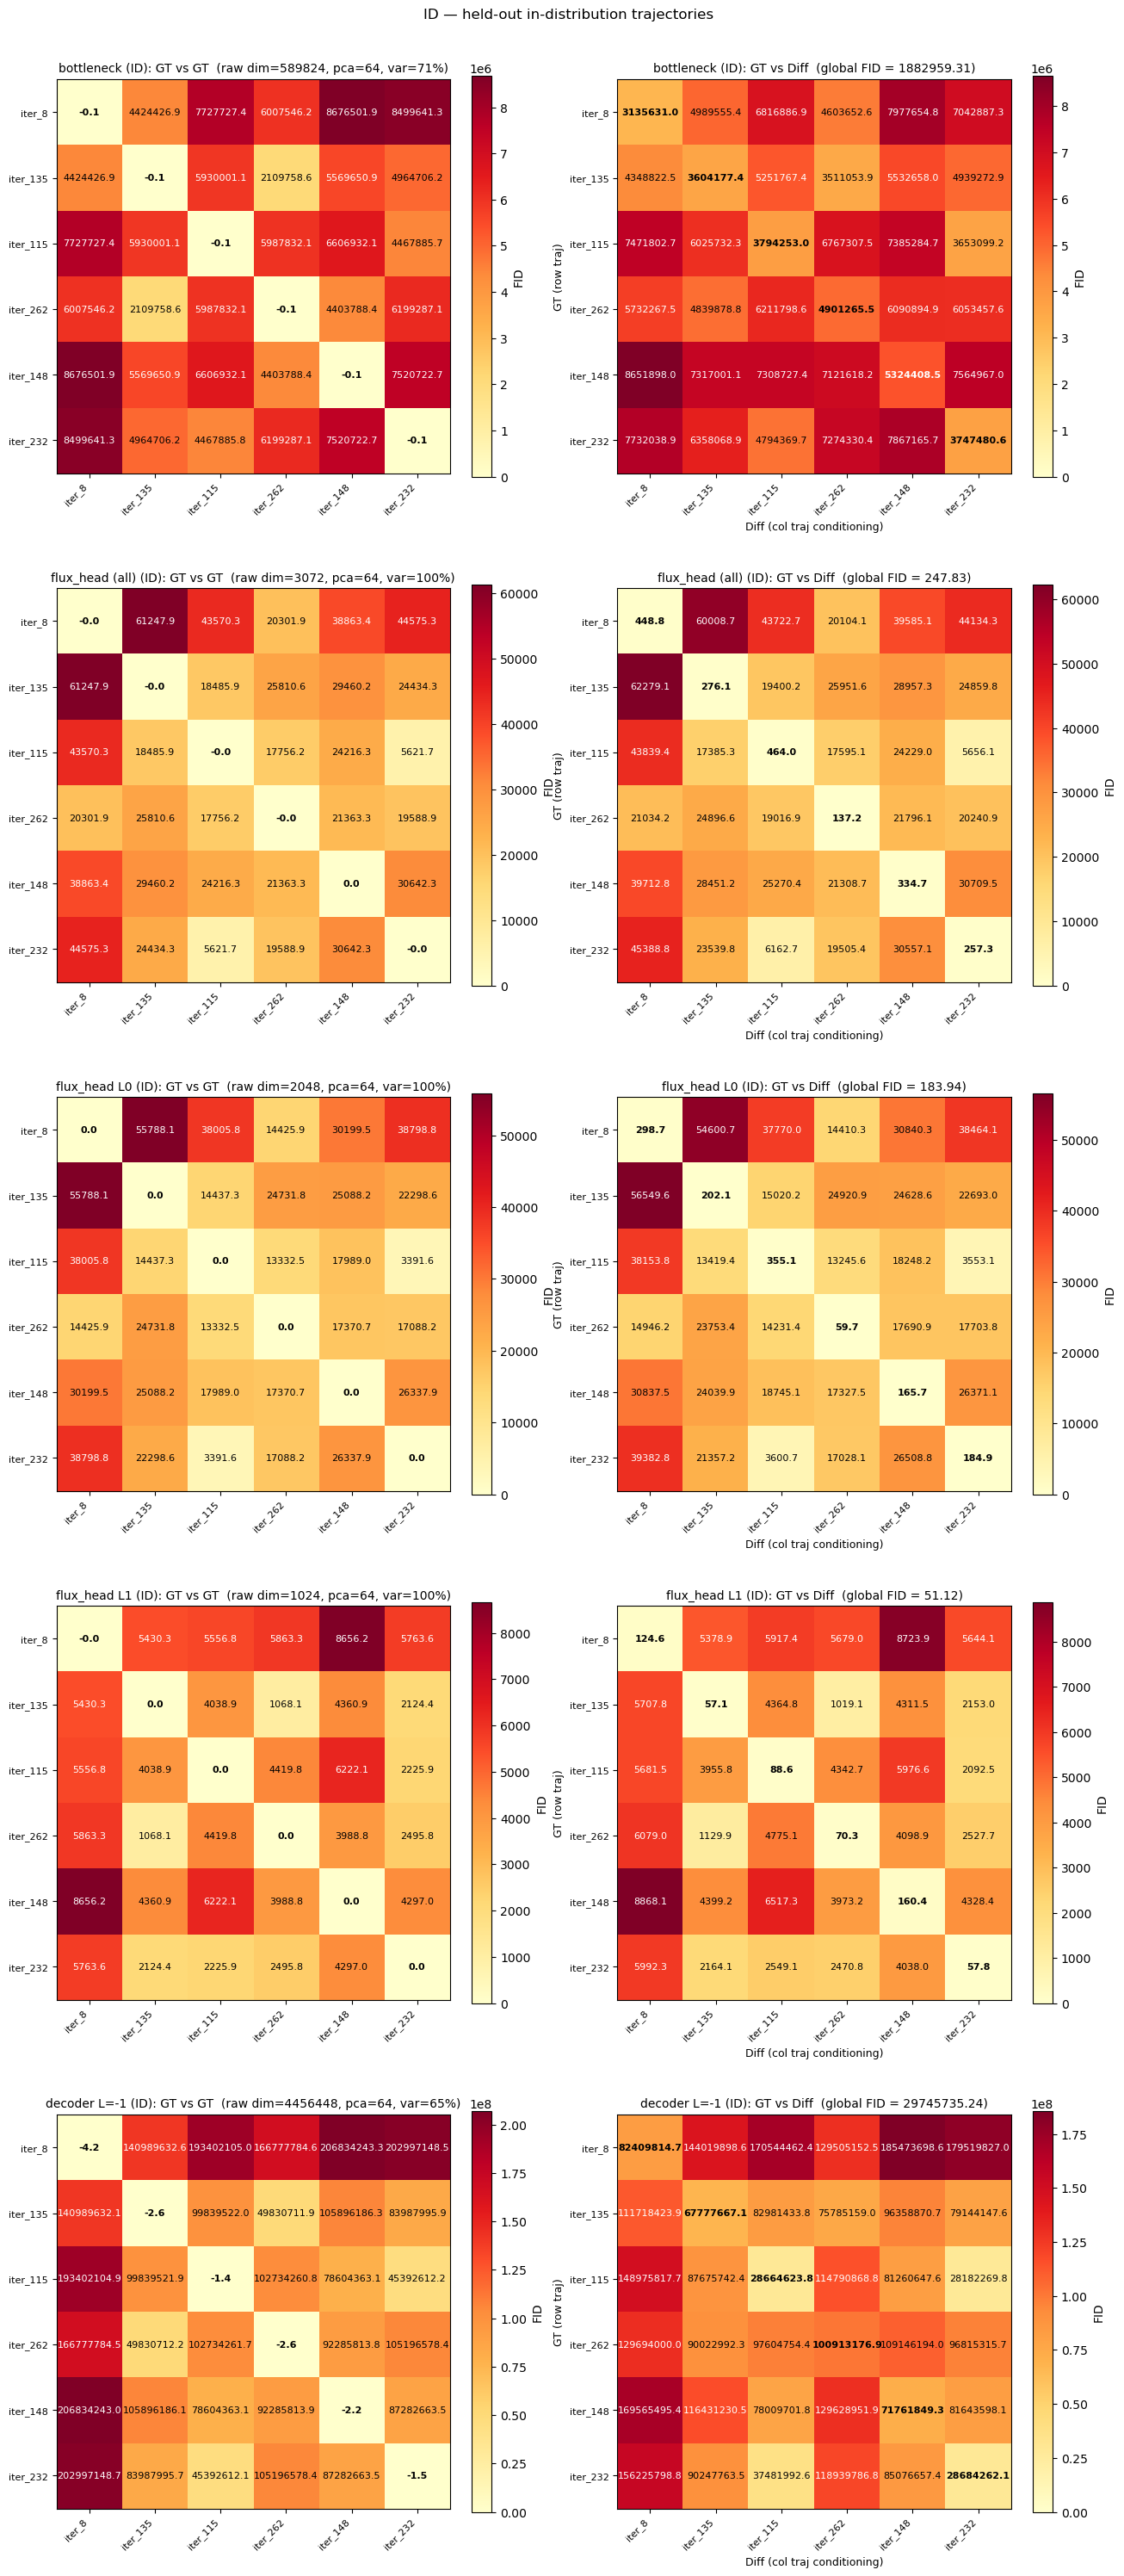

In [8]:
_id = {k: v for k, v in results.items() if k[1] == "ID"}
_ = plot_heatmap_grid(_id, title="ID — held-out in-distribution trajectories")

## Heatmaps — OOD

In [ ]:
_ood = {k: v for k, v in results.items() if k[1] == "OOD"}
_ = plot_heatmap_grid(_ood, title="OOD — out-of-distribution trajectories")

## Summary table

* `global_FID`              — pooled real vs pooled gen, on the shared PCA basis.
* `diag_FID(GT_i,Diff_i)`   — mean of per-traj FID where conditioning matches.
* `off_FID(GT_i,Diff_j)`    — mean of off-diagonal entries (pred vs wrong-traj GT).
* `GT-GT off-diag`          — reference scale: how distinguishable trajectories are in this latent space.

In [9]:
summary = build_table(results)
summary_sorted = summary.sort_index(level=["split", "latent"])
print(summary_sorted.to_string(float_format=lambda x: f"{x:.4g}"))
summary_sorted

                       raw_dim  pca_dim  var_explained  global_FID  diag_FID(GT_i,Diff_i)  off_FID(GT_i,Diff_j)  GT-GT off-diag
latent          split                                                                                                          
bottleneck      ID      589824       64         0.7059   1.883e+06              4.085e+06             6.241e+06        5.94e+06
decoder L=-1    ID     4456448       64         0.6496   2.975e+07              6.337e+07             1.101e+08       1.175e+08
flux_head (all) ID        3072       64         0.9993       247.8                  319.7             2.851e+04        2.84e+04
flux_head L0    ID        2048       64              1       183.9                    211               2.4e+04       2.395e+04
flux_head L1    ID        1024       64         0.9982       51.12                  93.12                  4495            4434
bottleneck      OOD     589824       64         0.7144   1.784e+06              3.973e+06             5.

,,raw_dim,pca_dim,var_explained,global_FID,"diag_FID(GT_i,Diff_i)","off_FID(GT_i,Diff_j)",GT-GT off-diag
latent,split,,,,,,,
bottleneck,ID,589824,64,0.705932,1.882959e+06,4.084536e+06,6.241197e+06,5.939761e+06
decoder L=-1,ID,4456448,64,0.649634,2.974574e+07,6.336857e+07,1.100824e+08,1.174701e+08
flux_head (all),ID,3072,64,0.999286,2.478275e+02,3.196962e+02,2.850998e+04,2.839590e+04
flux_head L0,ID,2048,64,0.999994,1.839407e+02,2.110369e+02,2.400140e+04,2.395227e+04
flux_head L1,ID,1024,64,0.998234,5.111703e+01,9.311869e+01,4.495327e+03,4.434122e+03
bottleneck,OOD,589824,64,0.714425,1.783543e+06,3.973096e+06,5.763588e+06,6.021773e+06
decoder L=-1,OOD,4456448,64,0.654234,4.211793e+07,8.056666e+07,1.131762e+08,1.258877e+08
flux_head (all),OOD,3072,64,0.999375,3.068328e+02,3.808021e+02,3.594558e+04,3.589290e+04
flux_head L0,OOD,2048,64,0.999995,1.032074e+02,1.263111e+02,3.133696e+04,3.162793e+04
